# Úkol č. 2 - Ensemble modely, klasifikace

* Termíny jsou uvedeny na [courses.fit.cvut.cz/BI-ML1/homeworks/index.html](https://courses.fit.cvut.cz/BI-ML1/homeworks/index.html).
* Pokud odevzdáte úkol po prvním termínu, ale před nejzazším termínem, budete penalizování -12 body, pozdější odevzdání je bez bodu.
* V rámci tohoto úkolu se musíte vypořádat s klasifikační úlohou, s příznaky různých typů.
* Před tím, než na nich postavíte predikční model, je třeba je nějakým způsobem převést do číselné reprezentace.
    
> **Úkol je zadány tak, aby Vám dal prostor pro invenci. Vymyslet _jak přesně_ budete úkol řešit, je důležitou součástí zadání a originalita či nápaditost bude také hodnocena.**
 
> **Minimalistické řešení nemůže získat plný počet bodů.**

Využívejte buňky typu `Markdown` k vysvětlování Vašeho postupu. Za nepřehlednost budeme strhávat body.

## Zdroj dat

Budeme se zabývat predikcí srdečního selhání u sledovaných osob.
K dispozici máte trénovací data v souboru `data.csv` a data na vyhodnocení v souboru `evaluation.csv`.

#### Seznam příznaků:

* Age: věk pacienta [roky]
* Sex: pohlaví pacienta [M: muž, F: žena]
* Chest Pain Type: typ bolesti na hrudi [TA: typická angina pectoris, ATA: atypická angina pectoris, NAP: neanginózní bolest, ASY: bez příznaků]
* Resting BP: krevní tlak v klidu [mm Hg]
* Cholesterol: sérový cholesterol [mm/dl]
* Fasting BS: hladina cukru v krvi nalačno [1: pokud BS nalačno > 120 mg/dl, 0: jinak]
* Resting ECG: výsledky elektrokardiogramu v klidu
[Normal: normální, ST: s abnormalitou ST-T vlny (inverze T vlny a/nebo elevace nebo deprese ST > 0,05 mV), LVH: s pravděpodobnou nebo definitivní hypertrofií levé komory podle Estesových kritérií].
* Max HR: maximální dosažená srdeční frekvence [Číselná hodnota mezi 60 a 202]
* Exercise Angina: angina pectoris vyvolaná zátěží [Y: Ano, N: Ne]
* Old peak: starý vrchol = ST [Číselná hodnota měřená v depresi]
* ST _Slope: sklon segmentu ST při maximální zátěži [Up: vzestupný, Flat: plochý, Down: sestupný]
* Heart Disease: **cílová proměnná, kterou máte predikovat** [1: srdeční onemocnění, 0: normální]

## Pokyny k vypracování

**Body zadání**, za jejichž (poctivé) vypracování získáte **25 bodů**: 
  * V notebooku načtěte data ze souboru `data.csv`. Vhodným způsobem si je rozdělte na podmnožiny, které Vám poslouží pro trénování (trénovací), porovnávání modelů (validační) a následnou predikci výkonnosti finálního modelu (testovací).✅
    
  * Proveďte základní předzpracování dat:
    * Projděte si jednotlivé příznaky a transformujte je do vhodné podoby pro použití ve vybraném klasifikačním modelu.✅
    * ~~Můžete využívat i vizualizace. Vše stručně, ale náležitě komentujte.~~

<br />

  * Vytvořte **vlastní implementaci náhodného lesa**. Použijte k tomu níže předpřipravenou kostru.✅
  
  * Na připravená data postupně aplikujte Vaši předchozí implementaci modelu náhodného lesa, dále alespoň dva z dalších modelů, které jsme se učili (**rozhodovací strom**✅, **metoda nejbližších sousedů**✅, **logistická regrese**✅, **AdaBoost**✅), přičemž pro každý z těchto modelů přiměřeně:
    * Okomentujte vhodnost daného modelu pro daný typ úlohy.✅
    * Experimentujte s normalizací (standardizace/min-max), pokud pro daný model očekáváte její příznivý vliv.✅
    * Vyberte si hlavní hyperparametry k ladění a najděte jejich nejlepší hodnoty (vzhledem k přesnosti).✅
    * Pro model s nejlepšími hodnotami hyperparametrů spočtěte (na validační množině) F1 skóre✅, nakreslete ROC křivku✅ a určete AUC✅. _Pozor na metodické chyby!_
    * Získané výsledky vždy řádně okomentujte.❌
<br />

  * Ze všech zkoušených možností v předchozím kroku vyberte finální model (jednoznačně popište o který konkrétně jde) a správně odhadněte, jakou **přesnost** můžete očekávat na nových datech, která jste doposud neměli k dispozici✅. _Pozor na metodické chyby!_
    
  * Nakonec načtěte vyhodnocovací data ze souboru `evaluation.csv`. Pomocí finálního modelu napočítejte predikce pro tyto data. Vytvořte soubor `results.csv`, ve kterém získané predikce uložíte do sloupce **HeartDisease** a jednotlivé body identifikujete pomocí sloupce **ID** (dodržte názvy sloupců!). Tento soubor též odevzdejte (uložte do repozitáře vedle notebooku)✅.

      * Snažte se vše udělat tak, aby přesnost odevzdaných predikcí na vyhodocovacím datasetu byla alespoň **80%**. Pokud bude menší, přijdete o **3 body**.
      * Ukázka, jak by mělo vypadat prvních několik řádků souboru `results.csv` (obecně s jinými hodnotami HeartDisease):
  
```
ID,HeartDisease
26,0
45,1
...
```


## Poznámky k odevzdání

  * Řiďte se pokyny ze stránky https://courses.fit.cvut.cz/BI-ML1/homeworks/index.html.

# Řešení

## Import balíčků

In [1]:
# Universal
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Data
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import ParameterGrid
from sklearn.impute import SimpleImputer

# Model
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# Score
from sklearn.metrics import f1_score, accuracy_score
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import confusion_matrix

# Randomness
from sklearn.utils import check_random_state
from scipy.stats import mode
rd_seed=42

## Příprava pro nejlepší model

In [2]:
# Best model storage
BEST_MODEL = {
    'model': None,
    'one-hot': None,
    'scaler': None,
    'params' : None,
    'accuracy': -1,
    'f1': -1,
    'auc': -1
}

# All models
MODELS = []

def update_best_model(model_name, one_hot, scaler, params, accuracy, f1, auc):
    """
    Aktualizuje BEST_MODEL, pokud je nová accuracy vyšší.
    """
    global BEST_MODEL
    
    # Create new model dict
    NEW_ENTRY = {
        'model': model_name,
        'one-hot': one_hot,
        'scaler': scaler,
        'params': params,
        'accuracy': accuracy,
        'f1': f1,
        'auc': auc
    }

    MODELS.append(NEW_ENTRY)
    MODELS.sort(key=lambda x: x['accuracy'], reverse=True)

    # Update global best model based on ACCURACY
    if accuracy > BEST_MODEL['accuracy']:
        BEST_MODEL = NEW_ENTRY.copy()
        print(f"--> Nový nejlepší model ({model_name} s acc {accuracy:.4f})")

def print_models(show_params=False):
    """
    Vypíše modely seřazené podle accuracy.
    """
    print(f"{'Model':<10} | {'Scaler':<10} | {'Accuracy':<10} | {'F1 Score':<10} | {'AUC':<10}")
    print("-" * 58)
    
    for m in MODELS:
        sc_str = str(m['scaler']) if m['scaler'] else "None"
        print(f"{m['model']:<10} | {sc_str:<10} | {m['accuracy']:.4f}     | {m['f1']:.4f}     | {m['auc']:.4f}")
        
    if show_params:
        print(f"\n\nParametry vítězného modelu ({BEST_MODEL['model']}):")
        print(f"\t{BEST_MODEL['params']}")

def plot_roc(model, model_name, Xv, yv):
    y_probs_full = model.predict_proba(Xv)
    y_probs = y_probs_full[:, 1] 

    fpr, tpr, thresholds = roc_curve(yv, y_probs)
    roc_auc = auc(fpr, tpr)

    print(f"Výsledné AUC skóre ({model_name}): {roc_auc:.4f}")

    # ROC curve
    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC křivka (AUC = {roc_auc:.2f})')

    # Random classifier baseline
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Náhodný odhad')

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('FPR')
    plt.ylabel('TPR')
    plt.title(f'ROC křivka - {model_name}')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()
    return roc_auc

## Načtení dat

In [3]:
data = pd.read_csv('data.csv')
data.drop(columns=['ID'], inplace=True)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 734 entries, 0 to 733
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             734 non-null    int64  
 1   Sex             734 non-null    object 
 2   ChestPainType   734 non-null    object 
 3   RestingBP       734 non-null    int64  
 4   Cholesterol     734 non-null    int64  
 5   FastingBS       734 non-null    int64  
 6   RestingECG      734 non-null    object 
 7   MaxHR           734 non-null    int64  
 8   ExerciseAngina  734 non-null    object 
 9   Oldpeak         734 non-null    float64
 10  ST_Slope        734 non-null    object 
 11  HeartDisease    734 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 68.9+ KB


## Rozdělení na trénovací/validační/testovací množiny

In [4]:
# 60/20/20
Xtrain, Xrest, ytrain, yrest = train_test_split(
    data.drop(columns=['HeartDisease']), data['HeartDisease'], test_size=0.4, random_state=rd_seed
)

Xval, Xtest, yval, ytest = train_test_split(
    Xrest, yrest, test_size=0.5, random_state=rd_seed
)

## Analýza dat

In [5]:
for col in data.columns:
    print(f"Printing unique '{col}':")
    print(*sorted(data[col].unique()))
    print()

Printing unique 'Age':
28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 74 75 76 77

Printing unique 'Sex':
F M

Printing unique 'ChestPainType':
ASY ATA NAP TA

Printing unique 'RestingBP':
0 80 92 94 95 96 98 100 101 102 104 105 106 108 110 112 113 114 115 117 118 120 122 123 124 125 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144 145 146 148 150 152 154 155 156 158 160 164 165 170 172 174 178 180 185 190 192 200

Printing unique 'Cholesterol':
0 85 100 110 113 117 123 126 129 132 139 141 142 147 149 152 153 156 159 160 161 164 165 167 168 169 170 171 172 173 174 175 176 177 178 179 180 181 182 183 184 185 186 187 188 190 192 193 194 195 196 197 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233 234 235 236 237 238 239 240 241 242 243 244 245 246 247 248 249 250 251 252 253 254 25

**Chybějící hodnoty:**
- RestingBP = 0
- Cholesterol = 0

In [6]:
# Change 0s to mean
cols_to_fix = ['RestingBP', 'Cholesterol']

imputer = SimpleImputer(missing_values=0, strategy='mean').fit(Xtrain[cols_to_fix])

Xtrain[cols_to_fix] = imputer.transform(Xtrain[cols_to_fix])
Xval[cols_to_fix]   = imputer.transform(Xval[cols_to_fix])
Xtest[cols_to_fix]  = imputer.transform(Xtest[cols_to_fix])

## Příprava dat

In [7]:
def process_data(d):
    df = d.copy()
    
    df['Sex'] = (df['Sex'] == 'M').astype(bool)    
    df['ExerciseAngina'] = (df['ExerciseAngina'] == 'Y').astype(bool)   
    
    cols_to_encode = ['ChestPainType', 'RestingECG', 'ST_Slope']
    df = pd.get_dummies(df, columns=cols_to_encode, drop_first=True, dtype=int)
    
    return df

Xtrain = process_data(Xtrain)
Xval   = process_data(Xval)
display(Xtrain)

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up
634,42,True,136.0,315.000000,0,125,True,1.8,0,0,0,1,0,1,0
332,68,False,120.0,211.000000,0,115,False,1.5,0,1,0,0,0,1,0
153,52,True,128.0,205.000000,1,184,False,0.0,1,0,0,1,0,0,1
75,52,True,130.0,241.444759,1,120,False,0.0,0,0,0,1,0,1,0
380,55,True,140.0,241.444759,0,150,False,0.2,1,0,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,56,True,130.0,221.000000,0,163,False,0.0,1,0,0,0,0,0,1
106,64,False,142.0,276.000000,0,140,True,1.0,0,0,0,1,0,1,0
270,64,True,130.0,223.000000,0,128,False,0.5,0,0,0,0,1,1,0
435,66,True,110.0,213.000000,1,99,True,1.3,0,1,0,0,0,1,0


## Modely

### Náhodný les (vlastní implementace)

**Vhodnost modelu:**
Random Forest je pro tuto úlohu velmi vhodným kandidátem. Jedná se o model, který kombinuje více rozhodovacích stromů, čímž snižuje riziko přeučení.
* **Výhody:** Dobře zvládá kombinaci numerických a kategorických dat, nevyžaduje nutně škálování a dokáže zachytit nelineární vztahy mezi příznaky.
* **Očekávání:** Očekávám vysokou přesnost.

In [8]:
class CustomRandomForest:
    """
    Třída Vašeho modelu
    Bude se jednat o model náhodného lesa, kde podmodely tvoří rozhodovací stromy pro klasifikaci.
    Pro podmodely můžete použít implementaci DecisionTreeClassifier ze sklearn.
    """
    def __init__(self, n_estimators=100, max_samples=None, max_depth=None, **kwargs):
        """
        Konstruktor modelu
        Základní hyperparametery:
            n_estimators - počet podmodelů - rozhodovacích stromů.
            max_samples - vyberte si, zda tento parametr bude označovat relativní počet bodů (tj. číslo mezi 0 a 1) 
                          nebo absolutní počet bodů (tj. číslo mezi 1 a velikostí trénovací množiny), 
                          které budou pro každý podmodel rozhodovacího stromu náhodně vybrány z trénovací množiny (bootstrap) a použity k jeho trénování.
            max_depth - maximální hloubka každého z podmodelů rozhodovacího stromu.
            kwargs - (volitelně) případné další hyperparametry, které pošlete do podmodelů rozhodovacího stromu
        """
        self.n_estimators = n_estimators
        self.max_samples = max_samples
        self.max_depth = max_depth
        self.kwargs = kwargs
        self.trees = []
        
    def fit(self, X, y):
        """
        Natrénování modelu. Trénovací data jsou v argumentech X a y.
        Pro trénování podmodelů používejte bootstraping a velikost samplovaného vzorku vezměte z hyperparametru max_samples
        """
        # Reset trees
        self.trees = []
        n_samples_total = X.shape[0]

        # Get the bootstrap size
        if isinstance(self.max_samples, float):
            sample_size = int(self.max_samples * n_samples_total)
        else:
            sample_size = self.max_samples

        X_arr = np.array(X)
        y_arr = np.array(y)

        for _ in range(self.n_estimators):
            # Bootstrap sampling
            #np.random.seed(rd_seed); worse with fixed random seed
            indices  = np.random.choice(n_samples_total, size=sample_size, replace=True)
            X_sample = X_arr[indices]
            y_sample = y_arr[indices]

            # Training a single tree
            tree = DecisionTreeClassifier(max_depth=self.max_depth, random_state=rd_seed, **self.kwargs)
            tree.fit(X_sample, y_sample)
            self.trees.append(tree)
        
    def predict(self, X):
        """
        Predikce y v zadaných bodech X
        """
        X_arr = np.array(X)
        tree_preds = np.array([tree.predict(X_arr) for tree in self.trees]).T
        
        # Majority voting
        votes = np.sum(tree_preds, axis=1)
        ypredicted = (votes >= (self.n_estimators / 2)).astype(int)
        return ypredicted

    def predict_proba(self, X):
        """
        Predikce pravděpodobností.
        """
        X_arr = np.array(X)

        tree_probs_class1 = np.array([tree.predict_proba(X_arr)[:, 1] for tree in self.trees]).T
        
        avg_prob_1 = np.mean(tree_probs_class1, axis=1)        
        avg_prob_0 = 1 - avg_prob_1

        return np.column_stack((avg_prob_0, avg_prob_1))

Uděláme si pomocnou funkci na natrénování nejlepšího lesa.

In [9]:
def tune_forest(Xt, yt, Xv, yv, custom=True):
    param_grid = {
        'n_estimators': range(50, 100, 10),
        'max_samples': [0.5, 0.8, 1.0],
        'max_depth': [3, 5, 10, None],
        'min_samples_split': [2, 5, 10],
    }
    
    param_comb = list(ParameterGrid(param_grid))
    
    best_acc = -1
    best_params = None
    best_f1 = -1
    
    for params in param_comb:
        if custom:
            model = CustomRandomForest(**params)
        else:
            model = RandomForestClassifier(**params, random_state=rd_seed)
            
        model.fit(Xt, yt)
        y_pred = model.predict(Xv)
        
        current_acc = accuracy_score(yv, y_pred)
        
        if current_acc > best_acc:
            best_acc = current_acc
            best_params = params
            best_f1 = f1_score(yv, y_pred)

    return best_params, best_acc, best_f1

In [10]:
best_params_forest, best_acc_forest, best_f1_forest = tune_forest(Xtrain, ytrain, Xval, yval, custom=True)

In [11]:
print(f"Nejlepší parametry:     {best_params_forest}")
print(f"Nejlepší přesnost:      {best_acc_forest:.4f}")
print(f"Nejlepší F1 skóre lesu: {best_f1_forest:.4f}")

Nejlepší parametry:     {'max_depth': 3, 'max_samples': 0.5, 'min_samples_split': 2, 'n_estimators': 50}
Nejlepší přesnost:      0.8639
Nejlepší F1 skóre lesu: 0.8837


In [12]:
model = CustomRandomForest(**best_params_forest)
model.fit(Xtrain, ytrain);

Výsledné AUC skóre (Random Forest): 0.8979


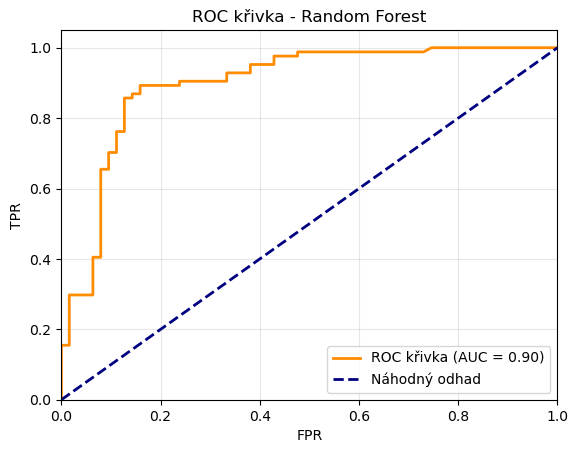

In [13]:
auc_forest = plot_roc(model, 'Random Forest', Xval, yval)

In [14]:
update_best_model(
    model_name='forest', one_hot=True, scaler=None,
    params=best_params_forest, accuracy=best_acc_forest,
    f1=best_f1_forest, auc=auc_forest
)

--> Nový nejlepší model (forest s acc 0.8639)


Můžeme ještě otestovat sci-kit implementaci náhodného lesu.

In [15]:
best_params_forest, best_acc_forest, best_f1_forest = tune_forest(Xtrain, ytrain, Xval, yval, custom=False)

In [16]:
print(f"Sci-kit params:   {best_params_forest}")
print(f"Sci-kit přesnost: {best_acc_forest:.4f}")
print(f"Sci-kit F1:       {best_f1_forest:.4f}")

Sci-kit params:   {'max_depth': None, 'max_samples': 1.0, 'min_samples_split': 5, 'n_estimators': 70}
Sci-kit přesnost: 0.8639
Sci-kit F1:       0.8864


Vidíme, že i u sci-kit implementace naḿ vyšla přesnost prakticky stejná a docela dobrá (86.4%). 

### Rozhodovací strom

**Vhodnost modelu:**
Rozhodovací stromy jsou intuitivní a jejich hlavní výhodou je interpretovatelnost – lze přesně vykreslit, podle jakých pravidel (např. Cholesterol > X) se model rozhoduje, což je v medicíně cenné.
* **Rizika:** Náchylný k přeučení.
* **Očekávání:** Pravděpodobně horší výsledky než Random Forest.

In [17]:
def tune_tree(Xt, yt, Xv, yv):
    """
    Ladí hyperparametry DecisionTreeClassifier na trénovacích (Xt) a validačních (Xv) datech.
    """
    param_grid = {
        'max_depth': [3, 5, 10, 15, None],
        'min_samples_leaf': [1, 2, 5, 10],
        'min_samples_split': [2, 5, 10, 20],
        'criterion': ['gini', 'entropy']
    }
    
    best_acc = -1
    best_params = None
    best_f1 = -1
    
    for params in ParameterGrid(param_grid):
        model = DecisionTreeClassifier(**params, random_state=rd_seed)
        model.fit(Xt, yt)
        y_pred = model.predict(Xv)
        
        # Optimalizace dle Accuracy
        current_acc = accuracy_score(yv, y_pred)
        
        if current_acc > best_acc:
            best_acc = current_acc
            best_params = params
            best_f1 = f1_score(yv, y_pred)

    return best_params, best_acc, best_f1

In [18]:
best_params_tree, best_acc_tree, best_f1_tree = tune_tree(Xtrain, ytrain, Xval, yval)

In [19]:
print(f"Nejlepší parametry stromu: {best_params_tree}")
print(f"Nejlepší přesnost stromu:  {best_acc_tree:.4f}")
print(f"Nejlepší F1 skóre stromu:  {best_f1_tree:.4f}")

Nejlepší parametry stromu: {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
Nejlepší přesnost stromu:  0.8299
Nejlepší F1 skóre stromu:  0.8571


In [20]:
model = DecisionTreeClassifier(**best_params_tree)
model.fit(Xtrain, ytrain);

Výsledné AUC skóre (Strom): 0.8101


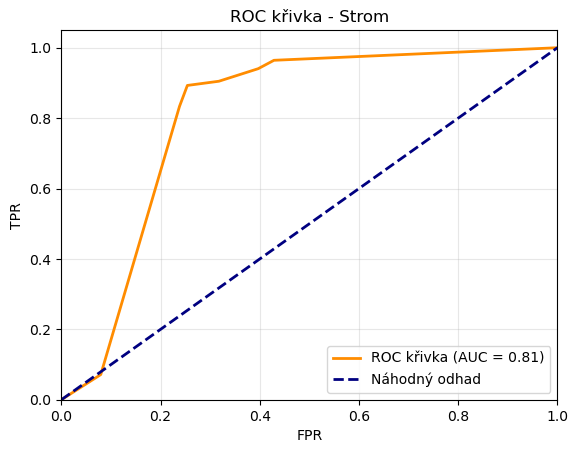

In [21]:
auc_tree = plot_roc(model, 'Strom', Xval, yval)

In [22]:
update_best_model(
    model_name='tree', one_hot=True, scaler=None,
    params=best_params_tree, accuracy=best_acc_tree,
    f1=best_f1_tree, auc=auc_tree
)

Skutečně, dostali jsme horší výsledek (83%).

### kNN

**Vhodnost modelu:**
kNN je založeno na myšlence, že pacienti s podobnými naměřenými hodnotami budou mít pravděpodobně stejnou diagnózu.
* **Očekávání:** kNN bude podle mě velmi silný model, zejména pokud by platilo, že skutečně pacientni s podobnými výsledky budou mít podobnou diagnózu.
* Je ale třeba data přeškálovat.

In [23]:
def tune_knn(Xt, yt, Xv, yv):
    scalers = [None, "standard", "minmax"]
    
    best_overall = {
        "scaler": None,
        "params": None,
        "accuracy": -1,
        "f1": -1
    }

    for sc_name in scalers:
        # Příprava dat (škálování)
        Xt_sc, Xv_sc = Xt.copy(), Xv.copy()
        if sc_name == "standard":
            scaler = StandardScaler()
            Xt_sc = scaler.fit_transform(Xt)
            Xv_sc = scaler.transform(Xv)
        elif sc_name == "minmax":
            scaler = MinMaxScaler()
            Xt_sc = scaler.fit_transform(Xt)
            Xv_sc = scaler.transform(Xv)

        param_grid = {
            'n_neighbors': range(1, 31, 2),
            'weights': ['uniform', 'distance'],
            'metric': ['minkowski', 'manhattan', 'euclidean'],
        }

        for params in ParameterGrid(param_grid):
            clf = KNeighborsClassifier(**params)
            clf.fit(Xt_sc, yt)
            y_pred = clf.predict(Xv_sc)
            
            # Optimalizace dle Accuracy
            current_acc = accuracy_score(yv, y_pred)

            if current_acc > best_overall["accuracy"]:
                best_overall["accuracy"] = current_acc
                best_overall["f1"] = f1_score(yv, y_pred)
                best_overall["params"] = params
                best_overall["scaler"] = sc_name
                
    return best_overall

In [24]:
best_knn = tune_knn(Xtrain, ytrain, Xval, yval)

In [25]:
print(f"Nejlepší parametry kNN: {best_knn['params']}")
print(f"Nejlepší scaler kNN:    {best_knn['scaler']}")
print(f"Nejlepší přesnost kNN:  {best_knn['accuracy']:.4f}")
print(f"Nejlepší f1 kNN:        {best_knn['f1']:.4f}")

Nejlepší parametry kNN: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
Nejlepší scaler kNN:    standard
Nejlepší přesnost kNN:  0.8776
Nejlepší f1 kNN:        0.8966


In [26]:
scaler = StandardScaler().fit(Xtrain)
Xt_sc = scaler.transform(Xtrain)
Xv_sc = scaler.transform(Xval)

model = KNeighborsClassifier(**best_knn['params'])
model.fit(Xt_sc, ytrain);

Výsledné AUC skóre (kNN): 0.8681


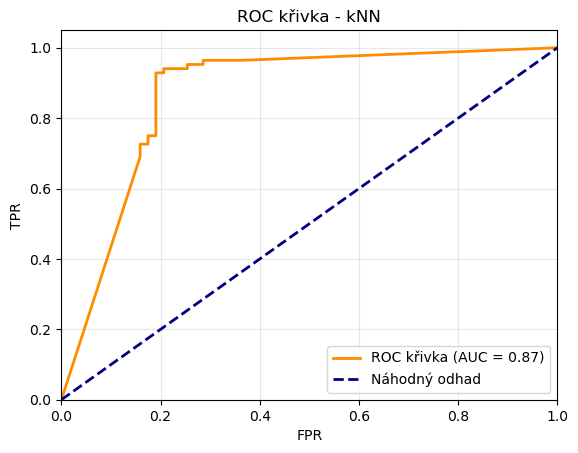

In [27]:
auc_knn = plot_roc(model, 'kNN', Xv_sc, yval)

In [28]:
update_best_model(
    model_name='knn', one_hot=True, scaler=best_knn['scaler'],
    params=best_knn['params'], accuracy=best_knn['accuracy'],
    f1=best_knn['f1'], auc=auc_knn
)

--> Nový nejlepší model (knn s acc 0.8776)


kNN se posouvá na 1. místo s nejleší přesností (87.8%).

### AdaBoost

**Vhodnost modelu:**
Postupně trénuje slabé modely a dává větší váhu těm vzorkům, které předchozí modely klasifikovaly špatně.
* **Výhody:** Často dosahuje vyšší přesnosti než Random Forest na čistých datech.
* **Rizika:** Je citlivější na šum v datech. Pokud dataset obsahuje chybná měření (což se u medicínských dat stává), AdaBoost se na ně může zbytečně fixovat.

In [29]:
def tune_adaboost(Xt, yt, Xv, yv):
    param_grid = {
        'n_estimators': [50, 100, 200, 300],
        'learning_rate': [0.01, 0.1, 0.5, 1.0, 1.5],
        'algorithm': ['SAMME'] 
    }
    
    best_acc = -1
    best_params = None
    best_f1 = -1

    for params in ParameterGrid(param_grid):
        clf = AdaBoostClassifier(**params, random_state=rd_seed)
        clf.fit(Xt, yt)
        y_pred = clf.predict(Xv)
        
        # Optimalizace dle Accuracy
        current_acc = accuracy_score(yv, y_pred)

        if current_acc > best_acc:
            best_acc = current_acc
            best_params = params
            best_f1 = f1_score(yv, y_pred)

    return best_params, best_acc, best_f1

In [30]:
best_ada_params, best_ada_acc, best_ada_f1 = tune_adaboost(Xtrain, ytrain, Xval, yval)

In [31]:
print(f"Nejlepší parametry AdaBoost: {best_ada_params}")
print(f"Nejlepší přesnost AdaBoost:  {best_ada_acc:.4f}")
print(f"Nejlepší f1 AdaBoost:        {best_ada_f1:.4f}")

Nejlepší parametry AdaBoost: {'algorithm': 'SAMME', 'learning_rate': 1.0, 'n_estimators': 50}
Nejlepší přesnost AdaBoost:  0.8639
Nejlepší f1 AdaBoost:        0.8837


In [32]:
model = AdaBoostClassifier(**best_ada_params, random_state=rd_seed)
model.fit(Xtrain, ytrain);

Výsledné AUC skóre (AdaBoost): 0.8928


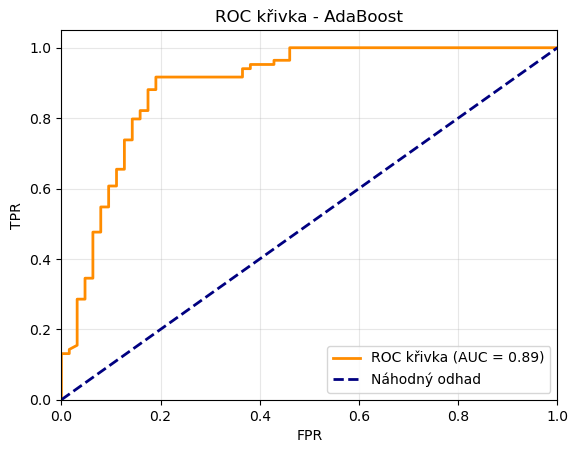

In [33]:
auc_ada = plot_roc(model, 'AdaBoost', Xval, yval)

In [34]:
update_best_model(
    model_name='ada', one_hot=True, scaler=None,
    params=best_ada_params, accuracy=best_ada_acc,
    f1=best_ada_f1, auc=auc_ada
)

AdaBoost skončil průměrně (86.4%).

### Logistická regrese

In [35]:
def tune_logreg(Xt, yt, Xv, yv):
    scalers = [None, "standard", "minmax"]
    
    best_overall = {
        "scaler": None,
        "params": None,
        "accuracy": -1,
        "f1": -1
    }

    for sc_name in scalers:
        Xt_sc, Xv_sc = Xt.copy(), Xv.copy()
        if sc_name == "standard":
            scaler = StandardScaler()
            Xt_sc = scaler.fit_transform(Xt)
            Xv_sc = scaler.transform(Xv)
        elif sc_name == "minmax":
            scaler = MinMaxScaler()
            Xt_sc = scaler.fit_transform(Xt)
            Xv_sc = scaler.transform(Xv)
            
        param_grid = {
            'C': [0.001, 0.01, 0.1, 1, 10, 100], 
            'penalty': ['l1', 'l2'],
            'solver': ['liblinear'],
            'class_weight': [None, 'balanced']
        }
        
        for params in ParameterGrid(param_grid):
            clf = LogisticRegression(**params, max_iter=2000, random_state=rd_seed)
            clf.fit(Xt_sc, yt)
            y_pred = clf.predict(Xv_sc)
            
            current_acc = accuracy_score(yv, y_pred)
            
            if current_acc > best_overall["accuracy"]:
                best_overall["accuracy"] = current_acc
                best_overall["f1"] = f1_score(yv, y_pred)
                best_overall["params"] = params
                best_overall["scaler"] = sc_name
                
    return best_overall

In [36]:
best_logreg = tune_logreg(Xtrain, ytrain, Xval, yval)

In [37]:
print(f"Nejlepší parametry logres: {best_logreg['params']}")
print(f"Nejlepší scaler logres:    {best_logreg['scaler']}")
print(f"Nejlepší přesnost logres:  {best_logreg['accuracy']:.4f}")
print(f"Nejlepší f1 logres:        {best_logreg['f1']:.4f}")

Nejlepší parametry logres: {'C': 1, 'class_weight': None, 'penalty': 'l1', 'solver': 'liblinear'}
Nejlepší scaler logres:    None
Nejlepší přesnost logres:  0.8639
Nejlepší f1 logres:        0.8851


In [38]:
model = LogisticRegression(**best_logreg['params'], max_iter=2000, random_state=rd_seed)
model.fit(Xtrain, ytrain); # Best scaler - None

Výsledné AUC skóre (Logistická regrese): 0.9004


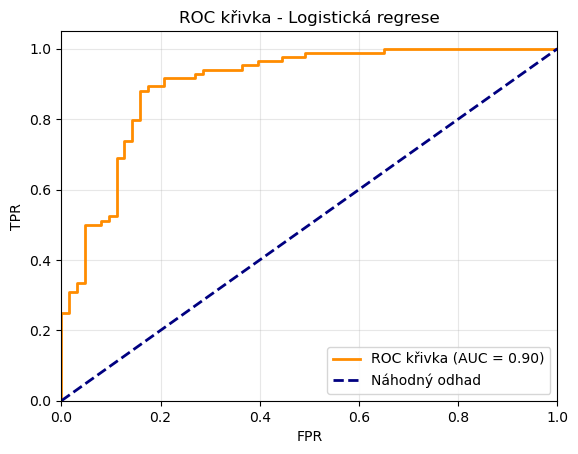

In [39]:
auc_logres = plot_roc(model, 'Logistická regrese', Xval, yval)

In [40]:
update_best_model(
    model_name='logres', one_hot=True, scaler=best_logreg['scaler'],
    params=best_logreg['params'], accuracy=best_logreg['accuracy'],
    f1=best_logreg['f1'], auc=auc_logres
)

Také průměrný výsledek (86.4%).

Můžeme porovnat všechny modely dohromady.

In [41]:
print_models(show_params=True)

Model      | Scaler     | Accuracy   | F1 Score   | AUC       
----------------------------------------------------------
knn        | standard   | 0.8776     | 0.8966     | 0.8681
forest     | None       | 0.8639     | 0.8837     | 0.8979
ada        | None       | 0.8639     | 0.8837     | 0.8928
logres     | None       | 0.8639     | 0.8851     | 0.9004
tree       | None       | 0.8299     | 0.8571     | 0.8101


Parametry vítězného modelu (knn):
	{'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}


### Souhrn
- **Nejlepší model** $-$ **kNN**
  * Podle **Přesnosti** nejlepší
  * Podle **F1** nejlepší
  * Ale druhé nejhorší **AUC**
- Odhadneme jakou přesnost můžeme očekávat na nových datech.

## Finální model

Jako nejlepší model nám vyšlo kNN.\
Připravíme si testovací množinu pro tento daný model.

In [42]:
Xtest    = process_data(Xtest)

In [43]:
scaler   = StandardScaler()
Xtrain_s = scaler.fit_transform(Xtrain)
Xval_s   = scaler.transform(Xval)
Xtest_s  = scaler.transform(Xtest) 

final = KNeighborsClassifier(**BEST_MODEL['params'])
final.fit(Xtrain_s, ytrain);

y_test_pred = final.predict(Xtest_s)

### Confusion Matrix

In [44]:
cfm_kNN = confusion_matrix(ytest, y_test_pred)

print("kNN")
print(cfm_kNN)

kNN
[[52 10]
 [10 75]]


Pro zajímavost z matice záměn vidíme, že u testovací množiny dostaneme:
- 75 TP
- 52 TN
- 10 FP
- 10 FN

### Finální ROC

Výsledné AUC skóre (Nejlepší model - kNN): 0.9038


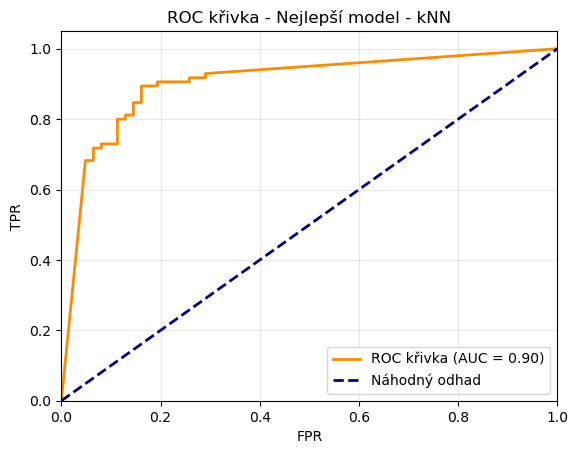

In [45]:
plot_roc(final, 'Nejlepší model - kNN', Xtest_s, ytest);

In [46]:
print(f'Očekávaná přesnost: {(accuracy_score(ytest, y_test_pred)):.4f}')

Očekávaná přesnost: 0.8639


## Evaluace dat

Už nám jen zbývá udělat skutečnou predikci.

In [47]:
# Read the data
eval_data = pd.read_csv('evaluation.csv')
eval_ids  = eval_data['ID'].copy()

# Process data
eval_data = eval_data.drop(columns=['ID'])
eval_data = process_data(eval_data)

# Prepare the data
scaler    = StandardScaler().fit(Xtrain)
eval_data = scaler.transform(eval_data)

# Predict
eval_pred = final.predict(eval_data)

# Store into DataFrame
results = pd.DataFrame({
    'ID':           eval_ids,
    'HeartDisease': eval_pred
})

# Save to CSV
results.to_csv('results.csv', index=False)

## Zdroje
  * Přednášky
  * Notebooky ze cvičení
  * Jazykové modely pro komentáře
  * Wikipedia